## 3.1- 양자 상태 토모그래피 (Quantum State Tomography)

In [1]:
# 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, circuit_drawer
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.result import Counts
from qiskit.quantum_info import DensityMatrix
from qiskit_aer import AerSimulator

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 양자 상태를 준비하는 함수
def prepare_state():
    qc = QuantumCircuit(1)
    qc.h(0)
    qc.s(0)
    return qc

In [3]:
# 여러 기저에서 측정을 수행하는 함수
def measure_in_bases(circuit):
    circuits = []

    # X 기저 측정
    qc_x = circuit.copy()
    qc_x.h(0)
    qc_x.measure_all()
    circuits.append(qc_x)

    # Y 기저 측정
    qc_y = circuit.copy()
    qc_y.sdg(0)
    qc_y.h(0)
    qc_y.measure_all()
    circuits.append(qc_y)

    # Z 기저 측정
    qc_z = circuit.copy()
    qc_z.measure_all()
    circuits.append(qc_z)

    return circuits

In [4]:
# 양자 상태 준비
qc = prepare_state()

Original Circuit:


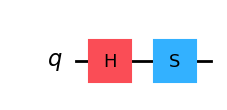

In [5]:
# 원본 회로 그리기
print("Original Circuit:")
circuit_drawer(qc, output='mpl')
plt.show()

In [6]:
# AerSimulator용으로 회로 트랜스파일
transpiled_qc = transpile(qc, backend=AerSimulator())

Transpiled Circuit:


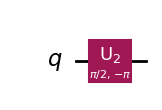

In [7]:
# 트랜스파일된 회로 그리기
print("Transpiled Circuit:")
circuit_drawer(transpiled_qc, output='mpl')
plt.show()

In [8]:
# 측정 회로 생성
measurement_circuits = measure_in_bases(qc)

In [9]:
# qiskit_aer의 AerSimulator 사용
simulator = AerSimulator()

In [10]:
# 회로 실행
results = simulator.run(measurement_circuits).result()

In [11]:
# 카운트 추출
counts_x = results.get_counts(measurement_circuits[0])
counts_y = results.get_counts(measurement_circuits[1])
counts_z = results.get_counts(measurement_circuits[2])

In [12]:
# 카운트에서 기댓값을 계산하는 함수
def expectation_value(counts):
    shots = sum(counts.values())
    exp_value = 0
    if '0' in counts:
        exp_value += counts['0'] / shots
    if '1' in counts:
        exp_value -= counts['1'] / shots
    return exp_value

In [13]:
# 블로흐 벡터 성분 계산
r_x = expectation_value(counts_x)
r_y = expectation_value(counts_y)
r_z = expectation_value(counts_z)

In [14]:
# 밀도행렬 재구성
rho = 0.5 * (np.eye(2) + r_x * np.array([[0, 1], [1, 0]]) + r_y * np.array([[0, -1j], [1j, 0]]) + r_z * np.array([[1, 0], [0, -1]]))

In [15]:
# 밀도행렬 출력
print("Reconstructed Density Matrix:")
print(rho)

Reconstructed Density Matrix:
[[ 0.484375+0.j       -0.015625+0.015625j]
 [-0.015625-0.015625j  0.515625+0.j      ]]


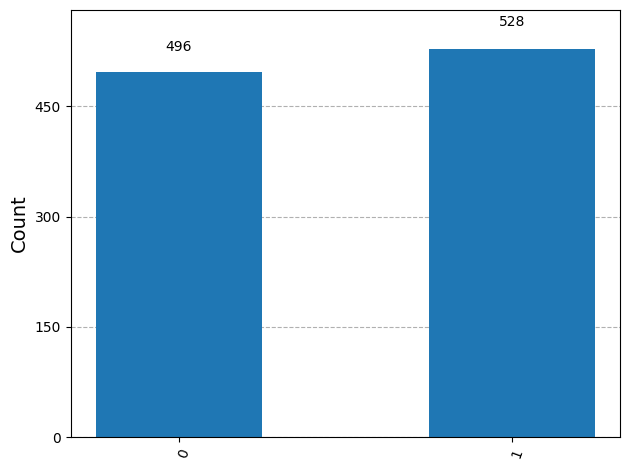

In [16]:
# 측정 결과 중 하나의 히스토그램 그리기
plot_histogram(counts_z)
plt.show()